In [68]:
# Load your files
from google.colab import files
uploaded = files.upload()



Saving EDIT THIS_tract_covariates.dta to EDIT THIS_tract_covariates (1).dta
Saving EDIT THIS_tract_outcomes_simple.dta to EDIT THIS_tract_outcomes_simple (1).dta
Saving philly_routes.txt to philly_routes (1).txt
Saving philly_stop_times.txt to philly_stop_times (1).txt
Saving philly_stops.txt to philly_stops (1).txt


In [69]:

import pandas as pd
stops = pd.read_csv('philly_stops.txt')
routes = pd.read_csv('philly_routes.txt')
stop_times = pd.read_csv('philly_stop_times.txt')

#This allows us to see how many stops, routes, and stop-time records there are.
print(f"Total stops: {len(stops)}")
print(f"Total routes: {len(routes)}")
print(f"Total stop-time records: {len(stop_times)}")
#We run this just to see how our data is structured and to gauge how we should further conduct our code
print(f"\nExample stops:")
print(stops.head())
print(f"\nExample routes:")
print(routes.head())
print(f"\nExample stop times:")
print(stop_times.head(10))


Total stops: 13851
Total routes: 172
Total stop-time records: 2045404

Example stops:
  stop_id                         stop_name                        stop_desc  \
0       4    Roosevelt Blvd & Broad St - FS  0 W ROOSEVELT BLVD & N BROAD ST   
1       5           Roosevelt Blvd & 5th St      W ROOSEVELT BLVD & N 5TH ST   
2       7         Roosevelt Blvd & Pratt St        ROOSEVELT BLVD & PRATT ST   
3       8  Roosevelt Blvd & Cottman Av - FS     ROOSEVELT BLVD & COTTMAN AVE   
4       9         Roosevelt Blvd & Holme Av                   ROOSEVELT BLVD   

    stop_lat   stop_lon  location_type  parent_station  wheelchair_boarding  \
0  40.018128 -75.148887              0             NaN                    1   
1  40.023465 -75.133487              0             NaN                    1   
2  40.028754 -75.089524              0             NaN                    1   
3  40.044610 -75.053657              0             NaN                    1   
4  40.058496 -75.044312              0

In [70]:
import networkx as nx
import matplotlib.pyplot as plt

#Our network graph is called "G", as for graph
G = nx.Graph()

#This adds all the NODES we need to the graph
for idx, row in stops.iterrows():
    G.add_node(row['stop_id'], name=row['stop_name'], lat=row['stop_lat'], lon=row['stop_lon'])

print(f"Created {len(G.nodes())} nodes (stations)")


Created 13851 nodes (stations)


In [71]:
#to make our program understand we need to convert all of the values like
# "06:05:01" into seconds
def to_seconds(time_str):
  #defines h, m, and s, by spilting the numbers at the ":"
  h, m, s = map(int, time_str.split(':'))
  #calculates the total numbers of seconds
  return h * 3600 + m * 60 + s

#grouping by the trip ID, to see

#Groups all the trips with the same ID (on the same line) and orders them
#through the 1st, 2nd and 3rd trip on the journey
stop_times_sorted = stop_times.sort_values(by=['trip_id', 'stop_sequence'])
groups = stop_times_sorted.groupby('trip_id', sort=False)
#calculates total number of specific trips in the dataset
total_trips = stop_times_sorted['trip_id'].nunique()

#starting a loop that looks at one trip at a time
for trip_id, trip_data in stop_times.groupby('trip_id', sort=False):
  #the following three line convert columns into lists for faster indexing purposes
  stop_ids = trip_data['stop_id'].tolist()
  arrival_times = trip_data['arrival_time'].tolist()
  departure_times = trip_data['departure_time'].tolist()
  #trip_data is a mini-dataframe for each iteration that helps us construct this loop
  trip_data = trip_data.sort_values(by='stop_sequence')
  for i in range(len(trip_data) - 1):
    seconds_a = to_seconds(arrival_times[i])
    seconds_b = to_seconds(departure_times[i+1])
    #travel time = time of arrival - time of departure
    travel_time = seconds_b - seconds_a

#THE LAST ONE WINS LOGIC
    if travel_time > 0:
      G.add_edge(stop_ids[i], stop_ids[i+1], weight=travel_time)

print(f"Added {len(G.edges())} edges (connections)")

Added 15166 edges (connections)


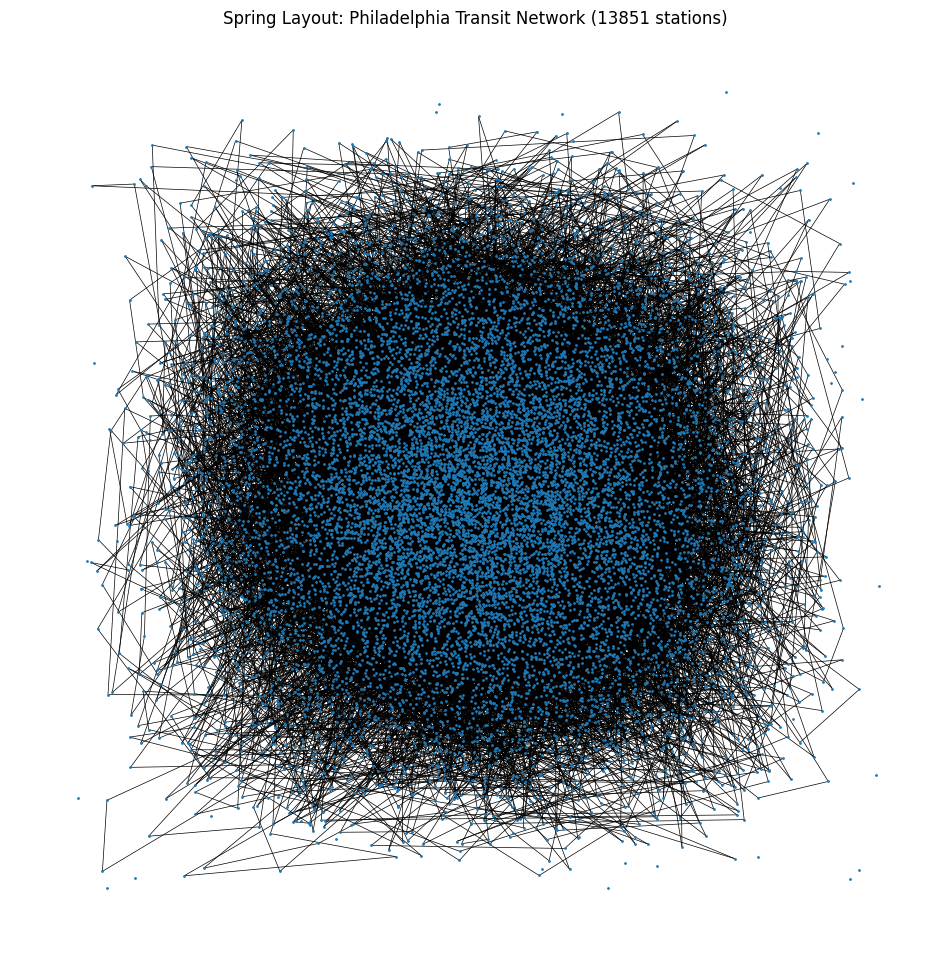

In [72]:
G = nx.relabel_nodes(G, {n: str(n) for n in G.nodes()})

pos = nx.spring_layout(G, iterations=10, seed=42)
plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G, pos, node_size=1)
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=0.5)
plt.title(f"Spring Layout: Philadelphia Transit Network ({len(G.nodes())} stations)")
plt.axis('off')
plt.show()

#note some nodes are not connected because of the nature of the data, where
#it shows inactive or abandoned stops


In [73]:
# Identify nodes that have zero connections (degree is 0)
isolated_nodes = [node for node, degree in dict(G.degree()).items() if degree == 0]

# Remove them from the graph 'G' directly
G.remove_nodes_from(isolated_nodes)

print(f"Removed {len(isolated_nodes)} ghost nodes. Active stations remaining: {len(G.nodes())}")

Removed 95 ghost nodes. Active stations remaining: 13756


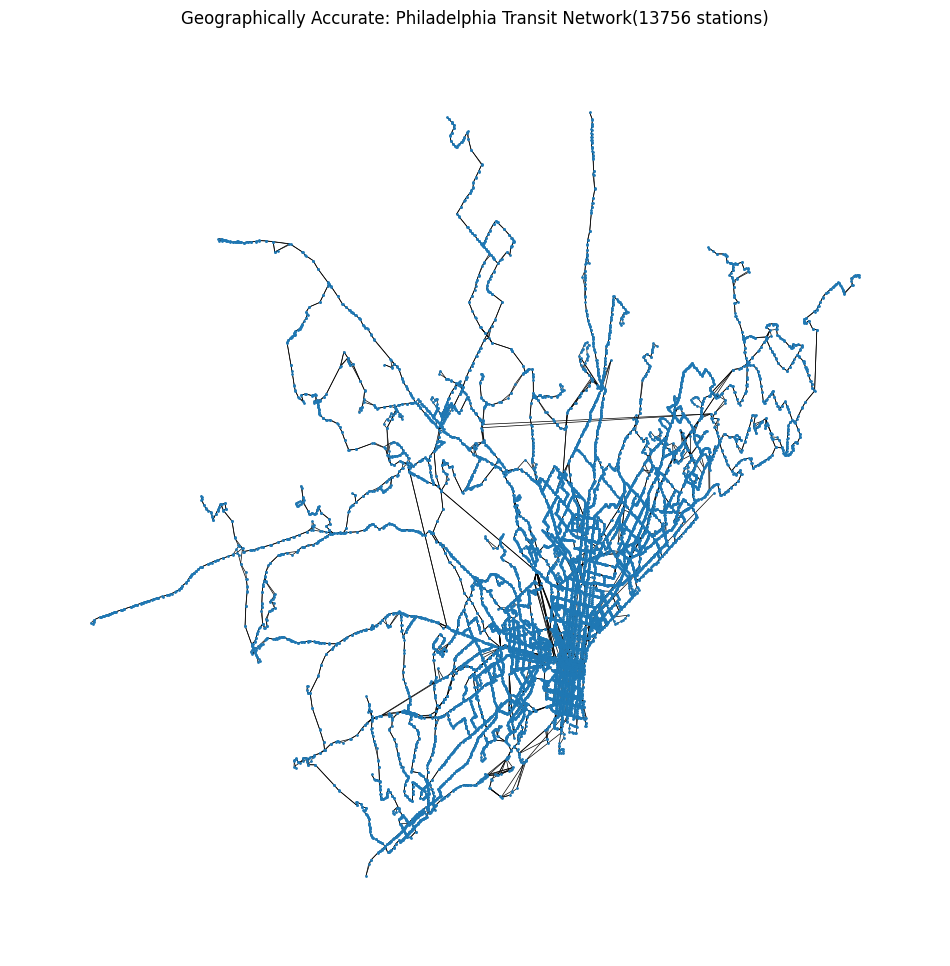

In [74]:

G = nx.relabel_nodes(G, {n: str(n) for n in G.nodes()})
pos = {row['stop_id']: (row['stop_lon'], row['stop_lat'])
  for _, row in stops.iterrows()}
plt.figure(figsize=(12, 12))
#decrease node_size to see graph better
nx.draw_networkx_nodes(G, pos, node_size=1)
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=0.5)
plt.title(f"Geographically Accurate: Philadelphia Transit Network({len(G.nodes())} stations)")
plt.axis('off')
plt.show()

In [75]:
#this code takes the nationwide census/oppurinity atlas

covariates = pd.read_stata('EDIT THIS_tract_covariates.dta')
outcomes = pd.read_stata('EDIT THIS_tract_outcomes_simple.dta')

philly_covariates = covariates[(covariates['state'] == 42) & (covariates['county'] == 101)].copy()
philly_outcomes = outcomes[(outcomes['state'] == 42) & (outcomes['county'] == 101)].copy()

print(f"Total covariates: {len(philly_covariates)} tracts")
print(f"Total outcomes: {len(philly_outcomes)} tracts")

philly_covariates.to_stata('philly_tract_covariates.dta', write_index=False)
philly_outcomes.to_stata('philly_tract_outcomes.dta', write_index=False)




Total covariates: 384 tracts
Total outcomes: 383 tracts


In [76]:
#Now that we have a matrix let's look at our two connectivity measures


#This is how closeness centrality is calculated:
#For a single node we calculate the summation the amount of time (the weighted
#links) to travel from that node to every other given node in the matrix
#we then take the reciporcal of that sum
closeness_centrality = nx.closeness_centrality(G, distance='weight')


#This is how betweenness centrality is calculated:
#We use all the pathways in the network, and find how many times a pathway
#goes through our node. We take the total number of times and divide that by
#the total number of pathways

#Using betweenness centrality was an idea from Joe Klienberg.

#IMPORTANT CAVEAT: we only use 1000 random* different pathways. There are SO
#MANY path combinations you can make, so doing this limits them. Even with this
#modification the code take around 8 minutes to run.

betweenness_centrality = nx.betweenness_centrality(G, weight='weight', k=1000, seed=42)

#creates a dataframe of our newly calculated measures!
connectivity_df = pd.DataFrame({'stop_id': list(closeness_centrality.keys()), 'closeness_centrality': list(closeness_centrality.values()), 'betweenness_centrality': [betweenness_centrality[n] for n in closeness_centrality.keys()]})
connectivity_df.to_csv('connectivity.csv', index=False)





In [77]:
connectivity_df = connectivity_df.merge(
    stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']],
    on='stop_id',
    how='left'
)
#Curious to test the most and least connected in the network!
print("Connectivity Scores (Top 5 Most Connected for each metric):")
print(connectivity_df.nlargest(5, 'closeness_centrality'))
print(connectivity_df.nlargest(5, 'betweenness_centrality'))


#Easy to have a score of zero on betweenness centrality because the 1000 routes
#may not include you.
print("\nConnectivity Scores (Top 10 Least Connected):")
print(connectivity_df.nsmallest(10, 'closeness_centrality'))



Connectivity Scores (Top 5 Most Connected for each metric):
      stop_id  closeness_centrality  betweenness_centrality  \
4015    18017              0.000445                0.061614   
13732   32990              0.000443                0.157503   
13733   32991              0.000443                0.046725   
13447   32269              0.000443                0.058018   
4310    18394              0.000443                0.077810   

                                               stop_name   stop_lat   stop_lon  
4015                             Ridge Av & I-76 Ramp FJ  40.014474 -75.204794  
13732  Ridge Av & Wissahickon Transit Center Boarding...  40.015132 -75.207837  
13733  Ridge Av & Wissahickon Transit Center Boarding...  40.015290 -75.207634  
13447                         Ridge Av & School House Ln  40.013085 -75.201950  
4310                        Ridge Av & I-76 Ramp FJ - FS  40.014277 -75.204535  
      stop_id  closeness_centrality  betweenness_centrality  \
653      114

In [78]:
# Load your files
from google.colab import files
uploaded = files.upload()

Saving philadelphia-neighborhoods.geojson to philadelphia-neighborhoods (1).geojson


In [79]:
#This chunk of code is how we link abstract code to actual geography
import geopandas as gpd
from shapely.geometry import Point

#loads in the Philly map dataset, borders are "polygons"
neighborhoods = gpd.read_file('philadelphia-neighborhoods.geojson')
#converts the latitue and langitude as "shapely points"
station_geometry = [
    Point(row['stop_lon'], row['stop_lat'])
    for idx, row in stops.iterrows()
]

#our table become a "GeoDataFrame"
station_gdf = gpd.GeoDataFrame(stops, geometry=station_geometry, crs='EPSG:4326')

#this is where the assignment occurs! checks to if the stop_id's point is in the
#polygon of the neighborhood
stations_with_neighborhoods = gpd.sjoin(
    station_gdf,
    neighborhoods,
    predicate='within',
    how='left'
)

#merges the closeness and betweeness scores to the table
connectivity_by_station = stations_with_neighborhoods.merge(
    connectivity_df[['stop_id', 'closeness_centrality', 'betweenness_centrality']],
    on='stop_id',
    how='left'
)

neighborhood_connectivity = connectivity_by_station.groupby('LISTNAME').agg({'closeness_centrality' : ['mean', 'std', 'count'], 'betweenness_centrality': ['mean', 'std'], 'stop_id' : 'count'}).reset_index()

print(f"Neighborhoods with highest connectivity")
print(neighborhood_connectivity.nlargest(10, ('closeness_centrality', 'mean')))

print(f"Neighrborhoods with lowest connectivity")
print(neighborhood_connectivity.nsmallest(10, ('closeness_centrality', 'mean')))

print(f"Neighborhoods with transit: {len(neighborhood_connectivity)}")
print(f"Total stations: {len(stops)}")

Neighborhoods with highest connectivity
                     LISTNAME closeness_centrality                  \
                                              mean       std count   
28                 East Falls             0.000431  0.000010    52   
149               Wissahickon             0.000426  0.000029    23   
2              Allegheny West             0.000420  0.000014    96   
8              Blue Bell Hill             0.000416  0.000005    10   
120                Roxborough             0.000414  0.000010    87   
54       Germantown, Westside             0.000408  0.000009    23   
133                     Tioga             0.000408  0.000032   102   
79                   Manayunk             0.000400  0.000009    28   
53   Germantown, West Central             0.000398  0.000018    55   
150         Wissahickon Hills             0.000398  0.000002     4   

    betweenness_centrality           stop_id  
                      mean       std   count  
28                0.02159

In [80]:
!pip install pygris -q
import pandas as pd
import geopandas as gpd
from pygris import tracts



#pygris is the library most commonly used to download official U.S. Census
#Bureau files

philly_tracts = tracts(state='PA', county='Philadelphia', year=2010, cache=True)
philly_tracts = philly_tracts.to_crs('EPSG:4326')
philly_tracts = philly_tracts.rename(columns={'GEOID10': 'GEOID'})
philly_tracts.to_file('philly_tracts.geojson', driver='GeoJSON')

income_data = pd.read_stata('philly_tract_outcomes.dta')
income_data['GEOID'] = (
    income_data['state'].astype(int).astype(str).str.zfill(2) +
    income_data['county'].astype(int).astype(str).str.zfill(3) +
    income_data['tract'].astype(int).astype(str).str.zfill(6)
)

tracts_with_income = philly_tracts.merge(income_data, on='GEOID', how='left')

tracts_in_nbhd = gpd.sjoin(
    tracts_with_income,
    neighborhoods,
    predicate='intersects',
    how='left'
)

income_by_neighborhood = tracts_in_nbhd.groupby('LISTNAME').agg({
    'kfr_pooled_pooled_p25': ['mean', 'std'],
    'jail_pooled_pooled_p25': ['mean', 'std'],
    'kfr_black_pooled_p25': ['mean', 'std'],
    'kfr_white_pooled_p25': ['mean', 'std'],
    'kfr_hisp_pooled_p25': ['mean', 'std']
}).reset_index()

#There was orginally some issue with
#Flatten the MultiIndex columns of income_by_neighborhood
income_by_neighborhood.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in income_by_neighborhood.columns.values]
# Rename 'LISTNAME' to 'LISTNAME_' to match neighborhood_connectivity
income_by_neighborhood = income_by_neighborhood.rename(columns={'LISTNAME': 'LISTNAME_'})

# Flatten the MultiIndex columns of neighborhood_connectivity
neighborhood_connectivity.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in neighborhood_connectivity.columns.values]
# Rename 'LISTNAME' to 'LISTNAME_' in neighborhood_connectivity to match income_by_neighborhood
neighborhood_connectivity = neighborhood_connectivity.rename(columns={'LISTNAME': 'LISTNAME_'}) # Ensure consistency for merging

analysis_data = neighborhood_connectivity.merge(
    income_by_neighborhood,
    left_on='LISTNAME_',
    right_on='LISTNAME_',
    how='left'
)

#now that we have connected it, let's see what the first 5 entries look like :)
print(f"Neighborhoods with connectivity and income: {len(analysis_data)}")
print(analysis_data.head())

Using FIPS code '42' for input 'PA'
Using FIPS code '101' for input 'Philadelphia'
Neighborhoods with connectivity and income: 158
          LISTNAME_  closeness_centrality_mean  closeness_centrality_std  \
0   Academy Gardens                   0.000286                  0.000006   
1           Airport                   0.000315                  0.000017   
2    Allegheny West                   0.000420                  0.000014   
3           Andorra                   0.000360                  0.000006   
4  Aston-Woodbridge                   0.000300                  0.000005   

   closeness_centrality_count  betweenness_centrality_mean  \
0                          29                     0.003000   
1                          19                     0.021979   
2                          96                     0.018539   
3                          19                     0.007079   
4                          28                     0.001793   

   betweenness_centrality_std  stop_id_

In [81]:
#this chunk is very similiar to the last one but groups on GEOID a key instead
#of name. This is the table we will primarly be using for analysis, but for the
#map at the end, we will use the former

!pip install pygris -q

from pygris import tracts

philly_tracts = tracts(state='PA', county='Philadelphia', year=2010, cache=True)
philly_tracts = philly_tracts.to_crs('EPSG:4326')
philly_tracts = philly_tracts.rename(columns={'GEOID10': 'GEOID'})
philly_tracts.to_file('philly_tracts.geojson', driver='GeoJSON')

stations_with_tracts = gpd.sjoin(
    station_gdf,
    philly_tracts,
    predicate='within',
    how='left'
)

connectivity_by_station = stations_with_tracts.merge(
    connectivity_df[['stop_id', 'closeness_centrality', 'betweenness_centrality']],
    on='stop_id',
    how='left'
)

tract_connectivity = connectivity_by_station.groupby('GEOID').agg({
    'closeness_centrality': ['mean', 'std', 'count'],
    'betweenness_centrality': ['mean', 'std'],
    'stop_id': 'count'
}).reset_index()

tract_connectivity.columns = ['_'.join(c).strip('_') for c in tract_connectivity.columns]

# Load income data (outcomes)
income_data = pd.read_stata('philly_tract_outcomes.dta')
income_data['GEOID'] = (
    income_data['state'].astype(int).astype(str).str.zfill(2) +
    income_data['county'].astype(int).astype(str).str.zfill(3) +
    income_data['tract'].astype(int).astype(str).str.zfill(6)
)

# Merge connectivity and outcome data
analysis_data = tract_connectivity.merge(income_data, on='GEOID', how='inner')

# Load covariate data (which contains med_hhinc2016)
covariate_data = pd.read_stata('philly_tract_covariates.dta')
covariate_data['GEOID'] = (
    covariate_data['state'].astype(int).astype(str).str.zfill(2) +
    covariate_data['county'].astype(int).astype(str).str.zfill(3) +
    covariate_data['tract'].astype(int).astype(str).str.zfill(6)
)

# Merge covariate data into analysis_data
analysis_data = analysis_data.merge(covariate_data[['GEOID', 'med_hhinc2016']], on='GEOID', how='left')


print(f"Tracts with connectivity, income, and covariates: {len(analysis_data)}")
print(analysis_data.head())

Using FIPS code '42' for input 'PA'
Using FIPS code '101' for input 'Philadelphia'
Tracts with connectivity, income, and covariates: 383
         GEOID  closeness_centrality_mean  closeness_centrality_std  \
0  42101000100                   0.000359                  0.000121   
1  42101000200                   0.000349                  0.000127   
2  42101000300                   0.000370                  0.000101   
3  42101000401                   0.000407                  0.000032   
4  42101000402                   0.000368                  0.000111   

   closeness_centrality_count  betweenness_centrality_mean  \
0                          40                     0.010703   
1                          18                     0.006924   
2                          34                     0.006966   
3                          15                     0.030786   
4                          30                     0.018227   

   betweenness_centrality_std  stop_id_count  state  county  tr

In [82]:
#1) Correlation
#checking the correlations between the kfr_pooled_pooled_25 and incentra
print(analysis_data[['closeness_centrality_mean', 'betweenness_centrality_mean', 'kfr_pooled_pooled_p25', 'jail_pooled_pooled_p25', 'med_hhinc2016']].corr())

                             closeness_centrality_mean  \
closeness_centrality_mean                     1.000000   
betweenness_centrality_mean                   0.336807   
kfr_pooled_pooled_p25                        -0.352743   
jail_pooled_pooled_p25                        0.166477   
med_hhinc2016                                 0.002022   

                             betweenness_centrality_mean  \
closeness_centrality_mean                       0.336807   
betweenness_centrality_mean                     1.000000   
kfr_pooled_pooled_p25                           0.085271   
jail_pooled_pooled_p25                         -0.174755   
med_hhinc2016                                   0.196569   

                             kfr_pooled_pooled_p25  jail_pooled_pooled_p25  \
closeness_centrality_mean                -0.352743                0.166477   
betweenness_centrality_mean               0.085271               -0.174755   
kfr_pooled_pooled_p25                     1.000000      

In [83]:
#TEST 2 TILL. TEST 5 LOOK AT KFR_POOLED_POOLED_25, WE THEN LOOK AT ANOTHER
#DEPENDENT VARIABLE, MEDIAN HH INCOME, AND REPEAT TESTS 2-5
#Test 2: OLS Regresssion with mutiple variable
#controlling for centrality and betweeness
import statsmodels.formula.api as smf
model = smf.ols(
    formula='kfr_pooled_pooled_p25 ~ closeness_centrality_mean + betweenness_centrality_mean',
    data=analysis_data
).fit()

print(model.summary())


                              OLS Regression Results                             
Dep. Variable:     kfr_pooled_pooled_p25   R-squared:                       0.175
Model:                               OLS   Adj. R-squared:                  0.171
Method:                    Least Squares   F-statistic:                     39.36
Date:                   Mon, 11 May 2026   Prob (F-statistic):           3.16e-16
Time:                           03:28:28   Log-Likelihood:                 452.39
No. Observations:                    373   AIC:                            -898.8
Df Residuals:                        370   BIC:                            -887.0
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [84]:
#Test3: isolate for closeness centrality
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Use kfr_pooled_pooled_p25 as outcome
X_closeness = analysis_data[['closeness_centrality_mean']].values
y_kfr = analysis_data['kfr_pooled_pooled_p25'].values

# Remove rows with missing values
mask = ~(np.isnan(X_closeness.flatten()) | np.isnan(y_kfr))
X_closeness_clean = X_closeness[mask]
y_kfr_clean = y_kfr[mask]

# Fit model
model_closeness = LinearRegression()
model_closeness.fit(X_closeness_clean, y_kfr_clean)
y_pred_closeness = model_closeness.predict(X_closeness_clean)
r2_closeness = r2_score(y_kfr_clean, y_pred_closeness)

print(f"Closeness Centrality → KFR (Upward Mobility)")
print(f"R²: {r2_closeness:.8f}")
print(f"Coefficient: {model_closeness.coef_[0]:.8f} per unit closeness")
print(f"Intercept: {model_closeness.intercept_:.8f}")
print(f"Observations: {len(y_kfr_clean)}")

Closeness Centrality → KFR (Upward Mobility)
R²: 0.12442730
Coefficient: -834.69086237 per unit closeness
Intercept: 0.67675761
Observations: 373


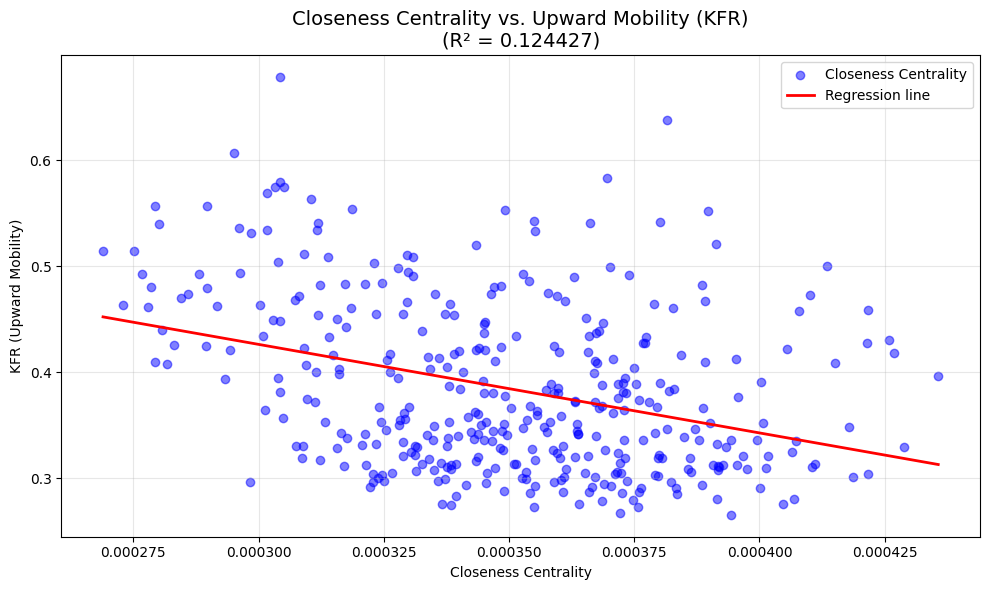

R²: 0.124427
Coefficient: -834.69086237


In [85]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data with KFR
df = analysis_data.dropna(subset=['kfr_pooled_pooled_p25', 'closeness_centrality_mean', 'betweenness_centrality_mean'])

# Closeness model (fitted earlier)
x = df['closeness_centrality_mean'].values
y_actual = df['kfr_pooled_pooled_p25'].values
x_sorted = np.sort(x)
y_line = model_closeness.predict(x_sorted.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.scatter(df['closeness_centrality_mean'], df['kfr_pooled_pooled_p25'], label='Closeness Centrality', alpha=0.5, color='blue')
plt.plot(x_sorted, y_line, label='Regression line', color='red', linewidth=2)
plt.xlabel('Closeness Centrality')
plt.ylabel('KFR (Upward Mobility)')
plt.title(f'Closeness Centrality vs. Upward Mobility (KFR)\n(R² = {r2_closeness:.6f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"R²: {r2_closeness:.6f}")
print(f"Coefficient: {model_closeness.coef_[0]:.8f}")

In [86]:
#Test4: isolate for betweeness centrality
X_betweenness = analysis_data[['betweenness_centrality_mean']].values

# Remove rows with missing values
mask = ~(np.isnan(X_betweenness.flatten()) | np.isnan(y_kfr))
X_betweenness_clean = X_betweenness[mask]
y_kfr_clean = y_kfr[mask]

# Fit model
model_betweenness = LinearRegression()
model_betweenness.fit(X_betweenness_clean, y_kfr_clean)
y_pred_betweenness = model_betweenness.predict(X_betweenness_clean)
r2_betweenness = r2_score(y_kfr_clean, y_pred_betweenness)

print(f"Betweenness Centrality → KFR (Upward Mobility)")
print(f"R²: {r2_betweenness:.8f}")
print(f"Coefficient: {model_betweenness.coef_[0]:.8f} per unit betweenness")
print(f"Intercept: {model_betweenness.intercept_:.8f}")
print(f"Observations: {len(y_kfr_clean)}")

Betweenness Centrality → KFR (Upward Mobility)
R²: 0.00727112
Coefficient: 1.08826267 per unit betweenness
Intercept: 0.37805617
Observations: 373


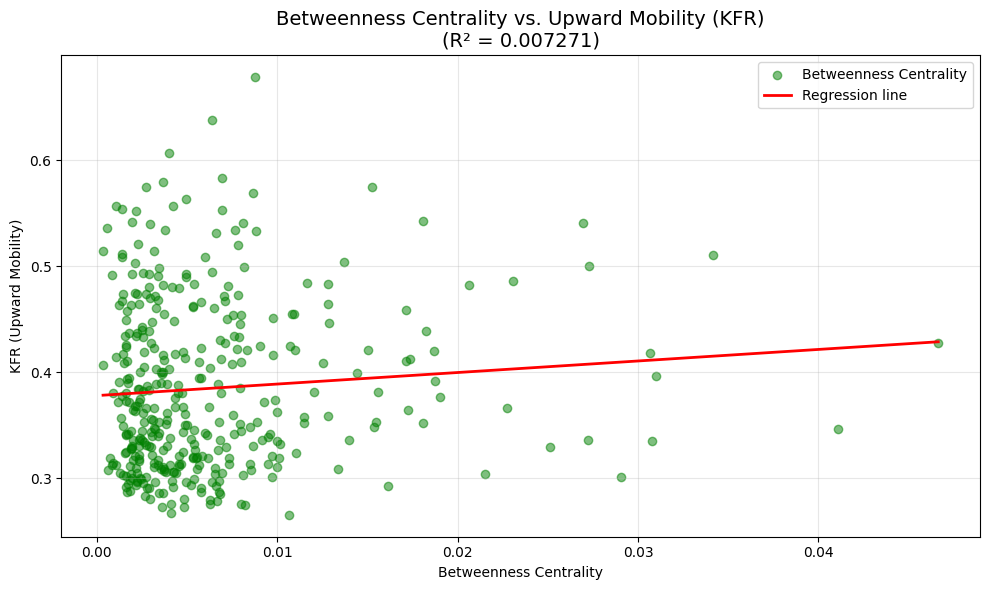

R²: 0.007271
Coefficient: 1.08826267


In [87]:
# Betweenness model (fitted earlier)
x = df['betweenness_centrality_mean'].values
y_actual = df['kfr_pooled_pooled_p25'].values
x_sorted = np.sort(x)
y_line = model_betweenness.predict(x_sorted.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.scatter(df['betweenness_centrality_mean'], df['kfr_pooled_pooled_p25'], label='Betweenness Centrality', alpha=0.5, color='green')
plt.plot(x_sorted, y_line, label='Regression line', color='red', linewidth=2)
plt.xlabel('Betweenness Centrality')
plt.ylabel('KFR (Upward Mobility)')
plt.title(f'Betweenness Centrality vs. Upward Mobility (KFR)\n(R² = {r2_betweenness:.6f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"R²: {r2_betweenness:.6f}")
print(f"Coefficient: {model_betweenness.coef_[0]:.8f}")

In [88]:
from sklearn.preprocessing import StandardScaler

#Test5: Standizing the betweeness centrality and the closeness centrality scores
#to compare them.

# Use both centrality measures
X_both = analysis_data[['closeness_centrality_mean', 'betweenness_centrality_mean']].values
y_kfr = analysis_data['kfr_pooled_pooled_p25'].values

# Remove rows with missing values
mask = ~(np.isnan(X_both).any(axis=1) | np.isnan(y_kfr))
X_both_clean = X_both[mask]
y_kfr_clean = y_kfr[mask]

# Fit model
model_both = LinearRegression()
model_both.fit(X_both_clean, y_kfr_clean)
y_pred_both = model_both.predict(X_both_clean)
r2_both = r2_score(y_kfr_clean, y_pred_both)

print(f"Both Centrality Measures → KFR (Upward Mobility)")
print(f"R²: {r2_both:.8f}")
print(f"\nCoefficients:")
print(f"  Closeness Centrality: {model_both.coef_[0]:.8f}")
print(f"  Betweenness Centrality: {model_both.coef_[1]:.8f}")
print(f"Intercept: {model_both.intercept_:.8f}")
print(f"Observations: {len(y_kfr_clean)}")

# Standardize both X and y
X_std = StandardScaler().fit_transform(X_both_clean)
y_kfr_std = (y_kfr_clean - y_kfr_clean.mean()) / y_kfr_clean.std()

# Fit standardized model
model_std = LinearRegression()
model_std.fit(X_std, y_kfr_std)

print(f"Standardized Coefficients → KFR (Upward Mobility)")
print(f"\nStandardized Coefficients:")
for name, coef in zip(['Closeness Centrality', 'Betweenness Centrality'], model_std.coef_):
    print(f"  {name}: {coef:.8f}")
print(f"Intercept: {model_std.intercept_:.8f}")
print(f"\nInterpretation:")
print(f"  Closeness: For every 1 std-dev increase, KFR changes {model_std.coef_[0]:.4f} std-devs")
print(f"  Betweenness: For every 1 std-dev increase, KFR changes {model_std.coef_[1]:.4f} std-devs")


Both Centrality Measures → KFR (Upward Mobility)
R²: 0.17545020

Coefficients:
  Closeness Centrality: -1038.66773034
  Betweenness Centrality: 3.08559085
Intercept: 0.72885066
Observations: 373
Standardized Coefficients → KFR (Upward Mobility)

Standardized Coefficients:
  Closeness Centrality: -0.43894371
  Betweenness Centrality: 0.24177168
Intercept: 0.00000025

Interpretation:
  Closeness: For every 1 std-dev increase, KFR changes -0.4389 std-devs
  Betweenness: For every 1 std-dev increase, KFR changes 0.2418 std-devs


In [89]:
#Income analysis for Households

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Define outcome variable
y_hhinc = analysis_data['med_hhinc2016'].values


print("Income analysis for Households")



#2) OLS Regression (Both Predictors)

print("\n\n2): OLS Regression (Both Centrality Measures) → Household Income")


import statsmodels.formula.api as smf

model_ols = smf.ols(
    formula='med_hhinc2016 ~ closeness_centrality_mean + betweenness_centrality_mean',
    data=analysis_data
).fit()

print(model_ols.summary())


#3) Closeness Only
print("\n\n3) Closeness Centrality Only → Household Income")


X_closeness = analysis_data[['closeness_centrality_mean']].values
mask = ~(np.isnan(X_closeness.flatten()) | np.isnan(y_hhinc))
X_closeness_clean = X_closeness[mask]
y_hhinc_clean = y_hhinc[mask]

model_closeness = LinearRegression()
model_closeness.fit(X_closeness_clean, y_hhinc_clean)
y_pred_closeness = model_closeness.predict(X_closeness_clean)
r2_closeness = r2_score(y_hhinc_clean, y_pred_closeness)

print(f"R²: {r2_closeness:.8f}")
print(f"Coefficient: {model_closeness.coef_[0]:.8f} per unit closeness")
print(f"Intercept: {model_closeness.intercept_:.8f}")
print(f"Observations: {len(y_hhinc_clean)}")


#4) Betweenness Only

print("\n\n4) Betweenness Centrality Only → Household Income")


X_betweenness = analysis_data[['betweenness_centrality_mean']].values
mask = ~(np.isnan(X_betweenness.flatten()) | np.isnan(y_hhinc))
X_betweenness_clean = X_betweenness[mask]
y_hhinc_clean = y_hhinc[mask]

model_betweenness = LinearRegression()
model_betweenness.fit(X_betweenness_clean, y_hhinc_clean)
y_pred_betweenness = model_betweenness.predict(X_betweenness_clean)
r2_betweenness = r2_score(y_hhinc_clean, y_pred_betweenness)

print(f"R²: {r2_betweenness:.8f}")
print(f"Coefficient: {model_betweenness.coef_[0]:.8f} per unit betweenness")
print(f"Intercept: {model_betweenness.intercept_:.8f}")
print(f"Observations: {len(y_hhinc_clean)}")


#5) Both Together (Unstandardized then into standardized)

print("\n\n5) Both Centrality Measures (Unstandardized) → Household Income")


X_both = analysis_data[['closeness_centrality_mean', 'betweenness_centrality_mean']].values
mask = ~(np.isnan(X_both).any(axis=1) | np.isnan(y_hhinc))
X_both_clean = X_both[mask]
y_hhinc_clean = y_hhinc[mask]

model_both = LinearRegression()
model_both.fit(X_both_clean, y_hhinc_clean)
y_pred_both = model_both.predict(X_both_clean)
r2_both = r2_score(y_hhinc_clean, y_pred_both)

print(f"R²: {r2_both:.8f}")
print(f"\nCoefficients:")
print(f"  Closeness Centrality: {model_both.coef_[0]:.8f}")
print(f"  Betweenness Centrality: {model_both.coef_[1]:.8f}")
print(f"Intercept: {model_both.intercept_:.8f}")
print(f"Observations: {len(y_hhinc_clean)}")

print("\n\n6) Both Centrality Measures (Standardized) → Household Income")


X_std = StandardScaler().fit_transform(X_both_clean)
y_hhinc_std = (y_hhinc_clean - y_hhinc_clean.mean()) / y_hhinc_clean.std()

model_std = LinearRegression()
model_std.fit(X_std, y_hhinc_std)

print(f"Standardized Coefficients:")
print(f"  Closeness Centrality: {model_std.coef_[0]:.8f}")
print(f"  Betweenness Centrality: {model_std.coef_[1]:.8f}")
print(f"Intercept: {model_std.intercept_:.8f}")

print(f"\nComparison (which matters more):")
if abs(model_std.coef_[0]) > abs(model_std.coef_[1]):
    ratio = abs(model_std.coef_[0] / model_std.coef_[1])
    print(f"  Closeness is {ratio:.2f}x stronger than Betweenness")
else:
    ratio = abs(model_std.coef_[1] / model_std.coef_[0])
    print(f"  Betweenness is {ratio:.2f}x stronger than Closeness")


#We report summary

print("Summary: Household Income Analysis")


summary_data = {
    'Test': ['Test 2: OLS', 'Test 3: Closeness', 'Test 4: Betweenness', 'Test 5: Both (Unstd)', 'Test 6: Both (Std)'],
    'R²': [f'{model_ols.rsquared:.8f}', f'{r2_closeness:.8f}', f'{r2_betweenness:.8f}', f'{r2_both:.8f}', 'N/A'],
    'Closeness Coef': [f'{model_ols.params[1]:.8f}', f'{model_closeness.coef_[0]:.8f}', 'N/A', f'{model_both.coef_[0]:.8f}', f'{model_std.coef_[0]:.8f}'],
    'Betweenness Coef': [f'{model_ols.params[2]:.8f}', 'N/A', f'{model_betweenness.coef_[0]:.8f}', f'{model_both.coef_[1]:.8f}', f'{model_std.coef_[1]:.8f}']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


#Key Findings

print("Key Findings: Household Income")

print(f"\n1. Closeness Centrality alone: R² = {r2_closeness:.8f}")
print(f"   → Explains {r2_closeness*100:.2f}% of household income variation")

print(f"\n2. Betweenness Centrality alone: R² = {r2_betweenness:.8f}")
print(f"   → Explains {r2_betweenness*100:.2f}% of household income variation")

print(f"\n3. Both together: R² = {r2_both:.8f}")
print(f"   → Explains {r2_both*100:.2f}% of household income variation")

print(f"\n4. Standardized comparison:")
print(f"   → Closeness effect: {model_std.coef_[0]:.6f} std-devs")
print(f"   → Betweenness effect: {model_std.coef_[1]:.6f} std-devs")

print(f"\n5. Interpretation:")
if r2_both < 0.05:
    print(f"   → Transit centrality is a WEAK predictor of household income")
elif r2_both < 0.15:
    print(f"   → Transit centrality is a MODERATE predictor of household income")
else:
    print(f"   → Transit centrality is a STRONG predictor of household income")

Income analysis for Households


2): OLS Regression (Both Centrality Measures) → Household Income
                            OLS Regression Results                            
Dep. Variable:          med_hhinc2016   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     8.547
Date:                Mon, 11 May 2026   Prob (F-statistic):           0.000235
Time:                        03:28:29   Log-Likelihood:                -4276.6
No. Observations:                 375   AIC:                             8559.
Df Residuals:                     372   BIC:                             8571.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------

/tmp/ipykernel_8382/1411078123.py:126: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Closeness Coef': [f'{model_ols.params[1]:.8f}', f'{model_closeness.coef_[0]:.8f}', 'N/A', f'{model_both.coef_[0]:.8f}', f'{model_std.coef_[0]:.8f}'],
/tmp/ipykernel_8382/1411078123.py:127: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Betweenness Coef': [f'{model_ols.params[2]:.8f}', 'N/A', f'{model_betweenness.coef_[0]:.8f}', f'{model_both.coef_[1]:.8f}', f'{model_std.coef_[1]:.8f}']


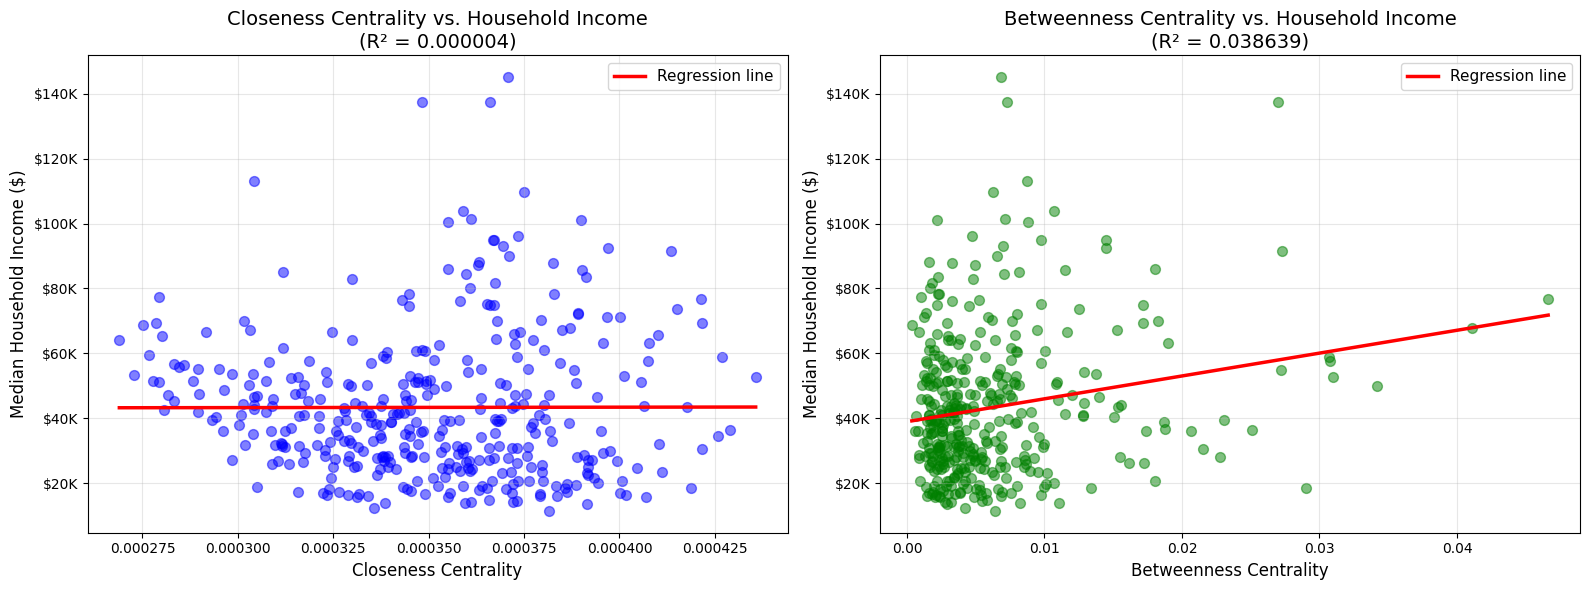

In [90]:
import matplotlib.pyplot as plt

# Prepare data
df = analysis_data.dropna(subset=['med_hhinc2016', 'closeness_centrality_mean', 'betweenness_centrality_mean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Plot 1: Closeness vs Household Income

x1 = df['closeness_centrality_mean'].values
y_actual = df['med_hhinc2016'].values
x1_sorted = np.sort(x1)
y_line1 = model_closeness.predict(x1_sorted.reshape(-1, 1))

axes[0].scatter(x1, y_actual, alpha=0.5, color='blue', s=50)
axes[0].plot(x1_sorted, y_line1, color='red', linewidth=2.5, label='Regression line')
axes[0].set_xlabel('Closeness Centrality', fontsize=12)
axes[0].set_ylabel('Median Household Income ($)', fontsize=12)
axes[0].set_title(f'Closeness Centrality vs. Household Income\n(R² = {r2_closeness:.6f})', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))


# Plot 2: Betweenness vs Household Income

x2 = df['betweenness_centrality_mean'].values
x2_sorted = np.sort(x2)
y_line2 = model_betweenness.predict(x2_sorted.reshape(-1, 1))

axes[1].scatter(x2, y_actual, alpha=0.5, color='green', s=50)
axes[1].plot(x2_sorted, y_line2, color='red', linewidth=2.5, label='Regression line')
axes[1].set_xlabel('Betweenness Centrality', fontsize=12)
axes[1].set_ylabel('Median Household Income ($)', fontsize=12)
axes[1].set_title(f'Betweenness Centrality vs. Household Income\n(R² = {r2_betweenness:.6f})', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

Some interpretation: It seems that transit centrality has a modest and mixed association to neighborhood income for Philadelphia. Tracts closer to the network's center, which means high closeness, have slightly lower incomes. However, tracts the serve as throuhput hubs on the shortest paths between places, so they have high betweenness, they seem to ahve higher incomes. So together, both measures explain for around 4% variance in tract level median income. This is a small effect, however it is one that motivates adding controls for race, poverty, and education, in order to see whather the relationship actually survives.

In [91]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


print("Random Forest Regression: Median Household Income")


# Define outcome and feature variables
y_hhinc = analysis_data['med_hhinc2016'].values
X_both = analysis_data[['closeness_centrality_mean', 'betweenness_centrality_mean']].values
mask = ~(np.isnan(X_both).any(axis=1) | np.isnan(y_hhinc))
X_both_clean = X_both[mask]
y_hhinc_clean = y_hhinc[mask]

model_rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_rf.fit(X_both_clean, y_hhinc_clean)
y_pred_rf = model_rf.predict(X_both_clean)
r2_rf = r2_score(y_hhinc_clean, y_pred_rf)

print(f"Random Forest R^2: {r2_rf:.8f}")

print(f" Feature Importance - Closeness: {model_rf.feature_importances_[0]:.3f}")
print(f" Feature Importance - Betweenness: {model_rf.feature_importances_[1]:.3f}")

Random Forest Regression: Median Household Income
Random Forest R^2: 0.39592281
 Feature Importance - Closeness: 0.428
 Feature Importance - Betweenness: 0.572


In [92]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


print("Random Forest Regression: KFR (Upward Mobility)")


# Define outcome and feature variables for KFR
y_kfr_rf = analysis_data['kfr_pooled_pooled_p25'].values
X_both_rf = analysis_data[['closeness_centrality_mean', 'betweenness_centrality_mean']].values

# Remove rows with missing values to ensure consistent sample size
mask_rf = ~(np.isnan(X_both_rf).any(axis=1) | np.isnan(y_kfr_rf))
X_both_clean_rf = X_both_rf[mask_rf]
y_kfr_clean_rf = y_kfr_rf[mask_rf]

# Initialize and fit the Random Forest Regressor model
model_rf_kfr = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_rf_kfr.fit(X_both_clean_rf, y_kfr_clean_rf)

# Predict and calculate R-squared
y_pred_rf_kfr = model_rf_kfr.predict(X_both_clean_rf)
r2_rf_kfr = r2_score(y_kfr_clean_rf, y_pred_rf_kfr)

print(f"Random Forest R^2 for KFR: {r2_rf_kfr:.8f}")

print("\nFeature Importances for KFR:")
print(f"  Closeness Centrality: {model_rf_kfr.feature_importances_[0]:.3f}")
print(f"  Betweenness Centrality: {model_rf_kfr.feature_importances_[1]:.3f}")

Random Forest Regression: KFR (Upward Mobility)
Random Forest R^2 for KFR: 0.49500669

Feature Importances for KFR:
  Closeness Centrality: 0.670
  Betweenness Centrality: 0.330


In [93]:
import folium

neighborhood_connectivity.columns = [
    '_'.join(c).strip() if isinstance(c, tuple) else c.strip('_')
    for c in neighborhood_connectivity.columns
]

m = folium.Map(location=[39.9526, -75.1652], zoom_start=11, tiles='OpenStreetMap'
)

neighborhoods_with_connectivity = neighborhoods.merge(
    neighborhood_connectivity,
    left_on='LISTNAME',
    right_on='LISTNAME',
    how='left'
)

folium.Choropleth(
    geo_data=neighborhoods_with_connectivity,
    name='choropleth',
    data=neighborhoods_with_connectivity,
    columns=['LISTNAME', 'closeness_centrality_mean'],
    key_on='feature.properties.LISTNAME',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Transit Connectivity (Closeness Centrality)'
).add_to(m)

m.save('philly_connectivity_choropleth.html')
print("Saved. Open philly_connectivity_choropleth.html in your browser")
#recommendation: doing betweenness centrality on the most popular paths in Philadelphia.
m

Saved. Open philly_connectivity_choropleth.html in your browser


In [94]:
m_betweenness = folium.Map(location=[39.9526, -75.1652], zoom_start=11, tiles='OpenStreetMap')

folium.Choropleth(
    geo_data=neighborhoods_with_connectivity,
    name='choropleth_betweenness',
    data=neighborhoods_with_connectivity,
    columns=['LISTNAME', 'betweenness_centrality_mean'],
    key_on='feature.properties.LISTNAME',
    fill_color='YlGnBu', # Using a different color scheme for distinction
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Transit Connectivity (Betweenness Centrality)'
).add_to(m_betweenness)

m_betweenness.save('philly_betweenness_choropleth.html')
print("Saved. Open philly_betweenness_choropleth.html in your browser")
m_betweenness

Saved. Open philly_betweenness_choropleth.html in your browser


In [95]:
%%shell
jupyter nbconvert --to html /content/AM50_Project-4.ipynb

[NbConvertApp] Converting notebook /content/AM50_Project-4.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 3954392 bytes to /content/AM50_Project-4.html
